In [1]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
import matplotlib.pyplot as plt
from pyspark.ml.clustering import KMeans

In [2]:
spark = (SparkSession.builder
            .appName("Preprocess")
            .getOrCreate()
  )

:: loading settings :: url = jar:file:/opt/spark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /root/.ivy2/cache
The jars for the packages stored in: /root/.ivy2/jars
graphframes#graphframes added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-03fba5fc-87d0-49b1-9eda-34b22f98b94a;1.0
	confs: [default]
	found graphframes#graphframes;0.8.3-spark3.5-s_2.12 in spark-packages
	found org.slf4j#slf4j-api;1.7.16 in central
:: resolution report :: resolve 107ms :: artifacts dl 3ms
	:: modules in use:
	graphframes#graphframes;0.8.3-spark3.5-s_2.12 from spark-packages in [default]
	org.slf4j#slf4j-api;1.7.16 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------------------------------------------------
	|      default     |   2   |   0   |   0   |   0   ||   2   |   0   |
	-----------------------------------------------

In [3]:
df = spark.read.parquet('/user/data/preprocess/kmeans/month=*/*.parquet')

# features = all cols of df
features = df.columns
assembler = VectorAssembler(
  inputCols=features, 
  outputCol="features",
  handleInvalid="skip"
)
df = assembler.transform(df).select("features")

26/03/20 16:10:45 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


K=2, WSS=6.363221957692579e+16


K=3, WSS=2.581695250378169e+16


K=4, WSS=1.210471933259781e+16


K=5, WSS=8860209004932705.0


K=6, WSS=5287797755934628.0


K=7, WSS=4640474883642167.0


K=8, WSS=2551532334340598.5


K=9, WSS=1459356704798709.8


K=10, WSS=1419798115443585.5


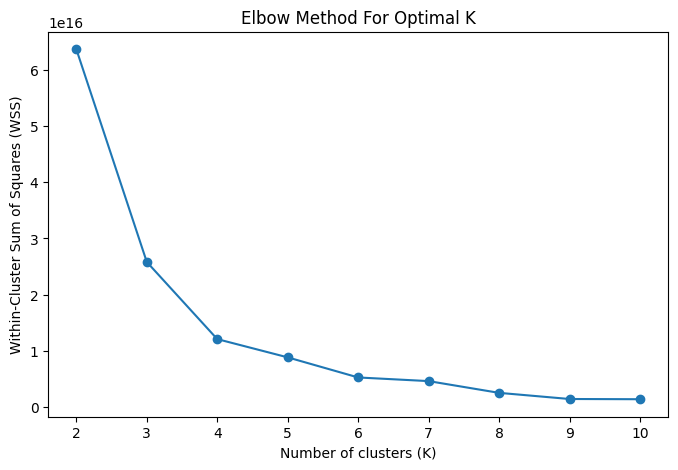

In [4]:
wss = []
for k in range(2, 11):
  kmeans = KMeans().setK(k).setSeed(42).setFeaturesCol("features")
  model = kmeans.fit(df)

  cost = model.summary.trainingCost
  wss.append(cost)
  print(f"K={k}, WSS={cost}")

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), wss, marker='o')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WSS)')
plt.show()